In [30]:
import pandas as pd

# Calculate the average score per category
avg_scores = df_trends.groupby('category')['score'].mean().reset_index()
avg_scores.columns = ['category', 'average_score']

# Sort by average score for better insight
avg_scores = avg_scores.sort_values(by='average_score', ascending=False)

print('Average Score per Category:')
display(avg_scores)

Average Score per Category:


,category,average_score
3,technology,300.840000
2,sports,191.307692
4,worldnews,177.588235
0,entertainment,144.920000
1,science,94.000000


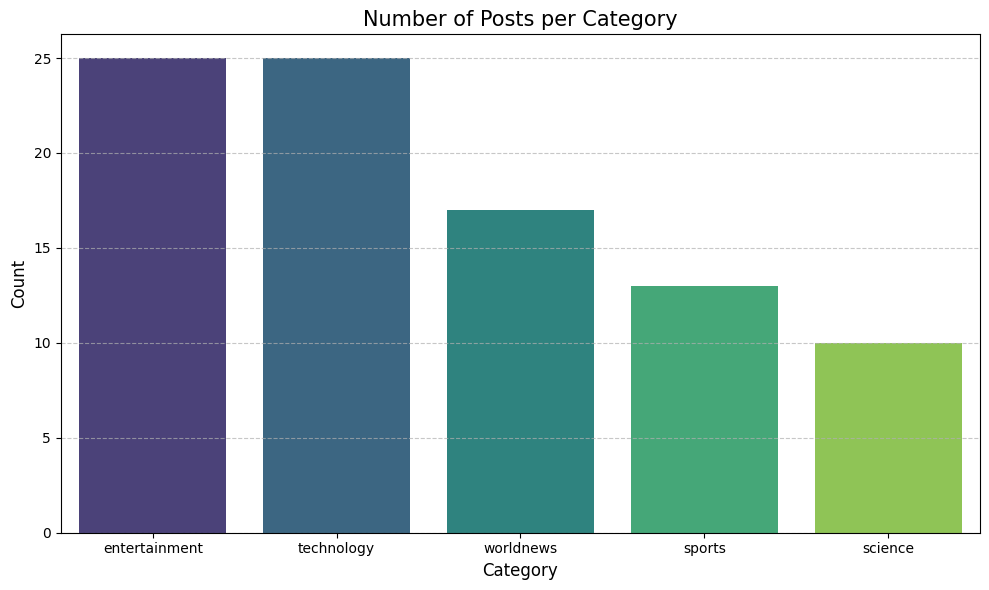

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the counts per category
category_counts = df_trends['category'].value_counts().reset_index()
category_counts.columns = ['category', 'count']

# Create the visualization
plt.figure(figsize=(10, 6))
sns.barplot(x='category', y='count', data=category_counts, palette='viridis', hue='category', legend=False)

# Add labels and title
plt.title('Number of Posts per Category', fontsize=15)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

In [20]:
import json

# Example of a malformed JSON string, similar to what caused the previous error
malformed_json_string = '''
{
    "name": "Example Item",
    "description": "This is a description that is cut off in the middle of a string...
'''

# Example of a valid JSON string
valid_json_string = '''
{
    "name": "Valid Item",
    "description": "This is a complete description."
}
'''

def load_json_with_error_handling(json_data_string):
    try:
        # Attempt to load the JSON data
        data = json.loads(json_data_string)
        print("Successfully loaded JSON data:")
        print(json.dumps(data, indent=2))
        return data
    except json.JSONDecodeError as e:
        # Handle JSON decoding errors
        print(f"JSON decoding error: {e}")
        print("Please ensure the JSON string is properly formatted and complete.")
        return None

print("\n--- Attempting to load malformed JSON ---")
malformed_data = load_json_with_error_handling(malformed_json_string)

print("\n--- Attempting to load valid JSON ---")
valid_data = load_json_with_error_handling(valid_json_string)

# If you were loading from a file, you would do:
# try:
#     with open('your_file.json', 'r') as f:
#         data = json.load(f)
#     print("Successfully loaded JSON from file.")
# except FileNotFoundError:
#     print("Error: File not found.")
# except json.JSONDecodeError as e:
#     print(f"JSON decoding error in file: {e}")


--- Attempting to load malformed JSON ---
JSON decoding error: Invalid control character at: line 4 column 87 (char 117)
Please ensure the JSON string is properly formatted and complete.

--- Attempting to load valid JSON ---
Successfully loaded JSON data:
{
  "name": "Valid Item",
  "description": "This is a complete description."
}


In [22]:
import requests # Used to make HTTP requests to the web

In [ ]:
import json     # Used to parse and save JSON data

In [ ]:
import os       # Used for interacting with the operating system (folder creation)

In [ ]:
from datetime import datetime # Used to get today's date for the filename

In [24]:
def fetch_reddit_data():
    # 1. Define the API endpoint for Reddit's popular posts (limit to 50 posts)
    url = "https://www.reddit.com/r/popular/top.json?limit=50"

    # 2. Reddit blocks default Python requests. We MUST provide a custom 'User-Agent' header.
    headers = {"User-Agent": "TrendPulse Data Pipeline v1.0 (by YourName)"}

    print("Fetching live data from Reddit...")

    # 3. Send the GET request to the URL with our custom headers
    response = requests.get(url, headers=headers)

    # 4. Check if the request was successful (HTTP Status Code 200)
    if response.status_code == 200:
        # 5. Convert the response text into a Python dictionary
        data = response.json()

        # 6. Ensure the 'data' directory exists; if not, create it
        os.makedirs("data", exist_ok=True)

        # 7. Generate today's date in YYYYMMDD format
        date_str = datetime.now().strftime("%Y%m%d")

        # 8. Create the dynamic filename based on today's date
        filename = f"data/trends_{date_str}.json"

        # 9. Open the file in write mode ('w') and save the JSON data
        with open(filename, "w") as file:
            # json.dump writes the dictionary to the file with an indent of 4 spaces for readability
            json.dump(data, file, indent=4)

        print(f"Success! Data saved to {filename}")
    else:
        # 10. If the request failed, print the error code
        print(f"Failed to fetch data. Status code: {response.status_code}")

In [25]:
import json
import os

# Define the filename to load
filename = "data/trends_20260405.json"

# Check if the file exists before attempting to load
if os.path.exists(filename):
    with open(filename, 'r', encoding='utf-8') as f:
        data = json.load(f)
    print(f"Contents of {filename}:")
    print(json.dumps(data, indent=4))
else:
    print(f"Error: File '{filename}' not found. Please ensure it has been created.")

Error: File 'data/trends_20260405.json' not found. Please ensure it has been created.


In [ ]:
# Run the function when the script executes
if __name__ == "__main__":
    fetch_reddit_data()

Fetching live data from Reddit...
Failed to fetch data. Status code: 403


In [26]:
import pandas as pd

# Assign the successfully loaded json_data to 'data'
data = json_data

# Now, create the DataFrame
df_trends = pd.DataFrame(data)

print("DataFrame created successfully. Here are the first 5 rows:")
display(df_trends.head())

DataFrame created successfully. Here are the first 5 rows:


,post_id,title,category,score,num_comments,author,collected_at
0,47673360,Show HN: Brutalist Concrete Laptop Stand (2024),entertainment,213,100,sam-bee,2026-04-07 14:54:00
1,47673005,We found an undocumented bug in the Apollo 11 ...,technology,204,118,henrygarner,2026-04-07 14:54:00
2,47674027,Show HN: A cartographer's attempt to realistic...,entertainment,67,13,intofarlands,2026-04-07 14:54:00
3,47675013,Dropping Cloudflare for Bunny.net,technology,132,57,shintoist,2026-04-07 14:54:00
4,47672295,Every GPU That Mattered,technology,197,107,jonbaer,2026-04-07 14:54:00


In [27]:
import requests
import time
import json
import os
from datetime import datetime

# Base URLs
TOP_STORIES_URL = "https://hacker-news.firebaseio.com/v0/topstories.json"
ITEM_URL = "https://hacker-news.firebaseio.com/v0/item/{}.json"

# Headers
headers = {"User-Agent": "TrendPulse/1.0"}

# Categories and keywords
CATEGORIES = {
    "technology": ["ai", "software", "tech", "code", "computer", "data", "cloud", "api", "gpu", "llm"],
    "worldnews": ["war", "government", "country", "president", "election", "climate", "attack", "global"],
    "sports": ["nfl", "nba", "fifa", "sport", "game", "team", "player", "league", "championship"],
    "science": ["research", "study", "space", "physics", "biology", "discovery", "nasa", "genome"],
    "entertainment": ["movie", "film", "music", "netflix", "game", "book", "show", "award", "streaming"]
}

# Function to assign category
def assign_category(title):
    title_lower = title.lower()
    for category, keywords in CATEGORIES.items():
        for keyword in keywords:
            if keyword in title_lower:
                return category
    return None


def main():
    collected_stories = []
    category_counts = {cat: 0 for cat in CATEGORIES}

    # Step 1: Fetch top story IDs
    try:
        response = requests.get(TOP_STORIES_URL, headers=headers)
        response.raise_for_status()
        story_ids = response.json()[:500]
    except Exception as e:
        print(f"Error fetching top stories: {e}")
        return

    # Step 2: Fetch each story
    for story_id in story_ids:
        try:
            response = requests.get(ITEM_URL.format(story_id), headers=headers)
            response.raise_for_status()
            story = response.json()
        except Exception as e:
            print(f"Error fetching story {story_id}: {e}")
            continue

        # Skip invalid stories
        if not story or "title" not in story:
            continue

        category = assign_category(story["title"])

        # Skip if no category match
        if category is None:
            continue

        # Skip if category already has 25
        if category_counts[category] >= 25:
            continue

        # Extract required fields
        data = {
            "post_id": story.get("id"),
            "title": story.get("title"),
            "category": category,
            "score": story.get("score", 0),
            "num_comments": story.get("descendants", 0),
            "author": story.get("by"),
            "collected_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        }

        collected_stories.append(data)
        category_counts[category] += 1

        # Stop when all categories have 25
        if all(count >= 25 for count in category_counts.values()):
            break

    # Sleep per category (as required)
    for _ in CATEGORIES:
        time.sleep(2)

    # Step 3: Save to JSON
    os.makedirs("data", exist_ok=True)

    filename = f"data/trends_{datetime.now().strftime('%Y%m%d')}.json"

    with open(filename, "w", encoding="utf-8") as f:
        json.dump(collected_stories, f, indent=4)

    print(f"Collected {len(collected_stories)} stories. Saved to {filename}")


if __name__ == "__main__":
    main()

Collected 90 stories. Saved to data/trends_20260407.json
